Single Decision Tree Accuracy: 100.00%
Bagging Classifier Accuracy: 100.00%


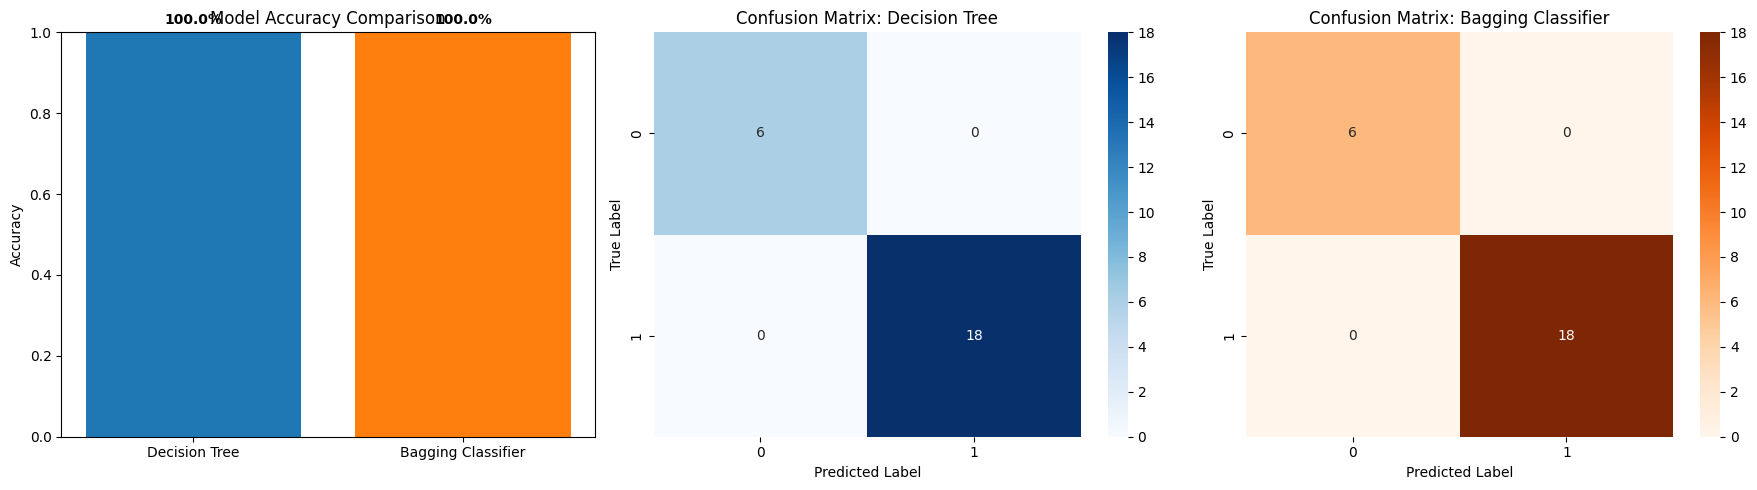

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Load the dataset
# Ensure 'diabetes_bassing.csv' is in the same directory as this script
try:
    df = pd.read_csv('diabetes_bagging.csv')
except FileNotFoundError:
    print("Error: 'diabetes_bassing.csv' not found. Please check the file name and path.")
    exit()

# Separate features (X) and target variable (y)
# Assuming the target column is named exactly 'Outcome'
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train a single Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)

# 3. Apply BaggingClassifier
# Note: In newer scikit-learn versions, use 'estimator' instead of 'base_estimator'
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100, # Number of trees in the ensemble
    random_state=42
)
bagging_model.fit(X_train, y_train)
bagging_predictions = bagging_model.predict(X_test)
bagging_accuracy = accuracy_score(y_test, bagging_predictions)

# 4. Compare accuracy (Print out results)
print(f"Single Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")
print(f"Bagging Classifier Accuracy: {bagging_accuracy * 100:.2f}%")

# ----------------- Visualizations -----------------

# Set up the matplotlib figure for subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Visualization 1: Accuracy comparison bar graph
models = ['Decision Tree', 'Bagging Classifier']
accuracies = [dt_accuracy, bagging_accuracy]
axes[0].bar(models, accuracies, color=['#1f77b4', '#ff7f0e'])
axes[0].set_ylim(0, 1.0) # Accuracy ranges from 0 to 1
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')

# Visualization 2: Confusion Matrix for Single Decision Tree
cm_dt = confusion_matrix(y_test, dt_predictions)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix: Decision Tree')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

# Visualization 3: Confusion Matrix for Bagging Classifier
cm_bagging = confusion_matrix(y_test, bagging_predictions)
sns.heatmap(cm_bagging, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('Confusion Matrix: Bagging Classifier')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()